<a href="https://colab.research.google.com/github/Namitha0203/CNN-Model-for-Intel-Image-Classification/blob/main/CNN_Model_for_Intel_Image_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
from tensorflow.keras import layers,models
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt


In [2]:
#Setting Hyperparameters
IMAGE_SIZE = 256
BATCH_SIZE = 32
CHANNELS = 3  #RGB
EPOCHS = 50

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("puneet6060/intel-image-classification")

print("Path to dataset files:", path)


Using Colab cache for faster access to the 'intel-image-classification' dataset.
Path to dataset files: /kaggle/input/intel-image-classification


In [4]:
#Listing Dataset Folders
import os
os.listdir(path)

['seg_train', 'seg_pred', 'seg_test']

In [5]:
train_path = os.path.join(path, "seg_train", "seg_train")
test_path  = os.path.join(path, "seg_test", "seg_test")
pred_path  = os.path.join(path, "seg_pred", "seg_pred")



In [6]:
train_path


'/kaggle/input/intel-image-classification/seg_train/seg_train'

In [7]:
import os

print(os.listdir(train_path))


['mountain', 'street', 'buildings', 'sea', 'forest', 'glacier']


In [8]:
#Creating Datasets
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_path,
    shuffle=True,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)


pred_ds = tf.keras.preprocessing.image_dataset_from_directory(
    pred_path,
    shuffle=True, # Keeping shuffle as original, though often false for prediction
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    labels=None # Explicitly set labels to None as prediction data typically doesn't have class subdirectories
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_path,
    shuffle=False,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

Found 14034 files belonging to 6 classes.
Found 7301 files.
Found 3000 files belonging to 6 classes.


In [9]:
#Extract Class Names
class_names = train_ds.class_names
class_names

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

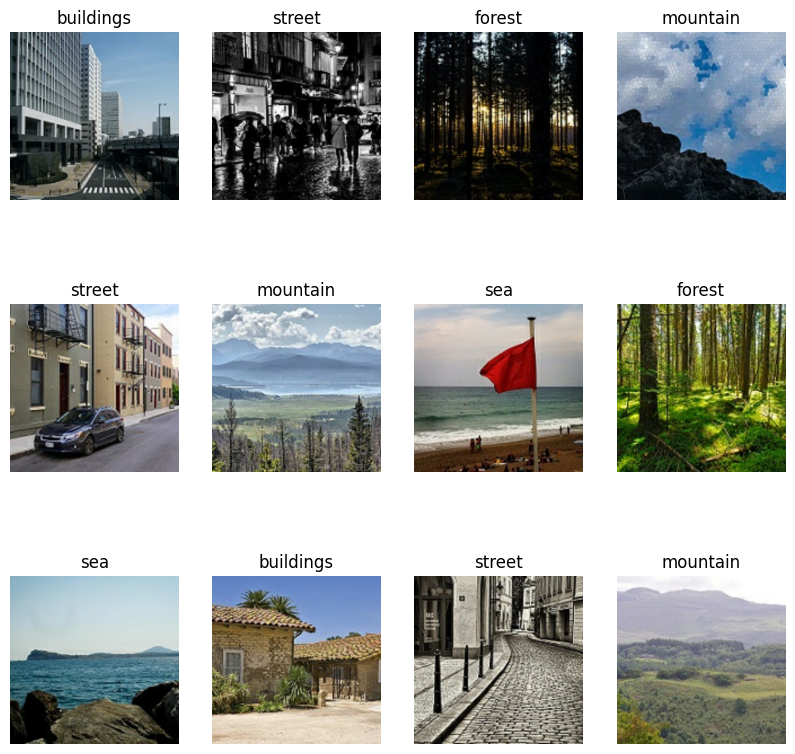

In [10]:
#Display Sample Images
plt.figure(figsize=(10,10))
for image_batch, label_batch in train_ds.take(1):
  for i in range(12):
    ax = plt.subplot(3,4,i+1)
    plt.imshow(image_batch[i].numpy().astype("uint8"))
    plt.title(class_names[label_batch[i]])
    plt.axis("off")

In [11]:
#Resize + Rescale Layer
resize_and_rescale = tf.keras.Sequential([
     layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),   # optional if image_dataset already resized
     layers.Rescaling(1.0/255)
])

In [12]:
# Data augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1),

])
#Helps prevent overfitting by creating variations of images.

In [13]:
AUTOTUNE = tf.data.AUTOTUNE

In [14]:
# The original train_ds contains all training data.
# We need to split it into a proper training set and a validation set.
# First, let's determine the number of batches for each split.
# Assuming an 80/20 split for train/validation.
train_ds_batches = tf.data.experimental.cardinality(train_ds).numpy()
val_ds_batches = int(train_ds_batches * 0.2) # 20% for validation

# Split the original train_ds into a new training set and the validation set.
# We'll take the first 20% for validation and the rest for training.
val_ds = train_ds.take(val_ds_batches)
train_ds_for_model = train_ds.skip(val_ds_batches)

# Now apply the resizing and rescaling to all datasets
train_ds = train_ds_for_model.map(
    lambda x, y: (resize_and_rescale(data_augmentation(x, training=True)), y),
    num_parallel_calls=AUTOTUNE
)
val_ds   = val_ds.map(lambda x, y: (resize_and_rescale(x), y), num_parallel_calls=AUTOTUNE)
test_ds  = test_ds.map(lambda x, y: (resize_and_rescale(x), y), num_parallel_calls=AUTOTUNE)

In [ ]:
plt.figure(figsize=(10,10))
for image_batch, label_batch in train_ds.take(1):
  for i in range(12):
    ax = plt.subplot(3,4,i+1)
    plt.imshow(image_batch[i].numpy())  # values are already 0.0–1.0, imshow handles that fine
    plt.title(class_names[label_batch[i]])
    plt.axis("off")

In [ ]:
#Building the CNN Model
input_shape = (IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
n_classes = 6 # Corrected from 3 to 6 to match the actual number of classes

model = models.Sequential([
    layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, CHANNELS)),  # add this as first layer
    layers.Conv2D(32, (3,3), activation='relu'),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),   # add
    layers.Dense(n_classes, activation='softmax')
])

# Build with only the image shape, no batch size
model.build(input_shape=(None, IMAGE_SIZE, IMAGE_SIZE, CHANNELS))


In [ ]:
model.summary()

In [ ]:
#Compile Model
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',      # stop based on validation loss
    patience=5,              # wait 5 epochs before stopping
    restore_best_weights=True,  # load best model weights
    min_delta=0.001          # minimum improvement required
)


In [ ]:
#Train the Model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[early_stop],
    verbose=1
)


In [ ]:
#Evaluate on Test Set
scores = model.evaluate(test_ds)

In [ ]:
#Extract Training Curves
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

In [ ]:


epochs_range = range(len(acc))   # number of epochs actually trained

plt.figure(figsize=(8, 8))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()


In [ ]:
#Predict First Test Image
for images_batch, labels_batch in test_ds.take(1):

    first_image = images_batch[0].numpy().astype('uint8')
    first_label = labels_batch[0].numpy()

    print("first image to predict")
    plt.imshow(first_image)
    print("actual label:",class_names[first_label])

    batch_prediction = model.predict(images_batch)
    print("predicted label:",class_names[np.argmax(batch_prediction[0])])


In [ ]:
test_list = list(test_ds.unbatch())
image_15, label_15 = test_list[40]   # 0-based index  11

image_15 = image_15.numpy().astype("uint8")
label_15 = label_15.numpy()

plt.imshow(image_15)
print("Actual label:", class_names[label_15])

prediction = model.predict(tf.expand_dims(image_15, axis=0))
print("Predicted:", class_names[np.argmax(prediction)])


In [ ]:
model.save("intel_image_classification_model.h5")


In [ ]:
loaded_model = tf.keras.models.load_model("potato_model.h5")


In [ ]:
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(img)  # use the 'img' parameter
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array)

    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * (np.max(predictions[0])), 2)
    return predicted_class, confidence

In [ ]:
plt.figure(figsize=(15, 15))
for images, labels in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))

        predicted_class, confidence = predict(model, images[i].numpy())
        actual_class = class_names[labels[i]]

        plt.title(f"Actual: {actual_class},\n Predicted: {predicted_class}.\n Confidence: {confidence}%")

        plt.axis("off")



In [ ]:
from sklearn.metrics import classification_report
import numpy as np

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred, target_names=class_names))


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
